In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt
import random  # used for random sampling

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define dataset directories
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/combined_fake_ecgs"

# Additional directories for real data (each will provide 50 random files)
ADDITIONAL_REAL_DIRS = [
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/cnn_fake",
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/pulse2pulse_fake",
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/timegan_fake",
    "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"
]

# Updated function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file
        ecg_data = np.loadtxt(file_path)
        # If the file has multiple columns, extract the first column; otherwise, use the data as is.
        if ecg_data.ndim > 1 and ecg_data.shape[1] > 1:
            lead_I = ecg_data[:, 0]
        else:
            lead_I = ecg_data
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def load_sequential_lead_I_from_directory(data_dir, n):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

def load_random_lead_I_from_directory(data_dir, n):
    # List all .asc files in the directory
    all_files = [f for f in os.listdir(data_dir) if f.endswith('.asc')]
    if len(all_files) < n:
        print(f"Warning: Requested {n} files but only found {len(all_files)} in {data_dir}.")
        selected_files = all_files
    else:
        selected_files = random.sample(all_files, n)
    
    lead_I_list = []
    for file_name in tqdm(selected_files, desc=f"Randomly loading Lead I from {os.path.basename(data_dir)}", unit='file'):
        file_path = os.path.join(data_dir, file_name)
        lead_I = load_lead_I_from_asc(file_path)
        if lead_I is not None:
            lead_I_list.append(lead_I)
    return np.array(lead_I_list)

# --------------------------
# Loading Real Data (Total = 2000 files)
# --------------------------
# Load 1800 sequential files from the real_ecgs folder.
lead_I_real_primary = load_sequential_lead_I_from_directory(DATA_DIR_REAL, 1800)

# Load 200 additional files by randomly selecting 50 files from each of the 4 additional directories.
lead_I_real_additional = []
for additional_dir in ADDITIONAL_REAL_DIRS:
    data = load_random_lead_I_from_directory(additional_dir, 50)
    lead_I_real_additional.append(data)

# Concatenate additional real data from all extra directories
lead_I_real_additional = np.concatenate(lead_I_real_additional, axis=0)

# Combine the primary and additional real data
lead_I_real = np.concatenate([lead_I_real_primary, lead_I_real_additional], axis=0)

# --------------------------
# Loading Fake Data (2000 sequential files)
# --------------------------
lead_I_fake = load_sequential_lead_I_from_directory(DATA_DIR_FAKE, 2000)

# Check if data was loaded successfully
if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")


Randomly loading Lead I from timegan_fake: 100%|██████████| 50/50 [00:00<00:00, 92.49file/s]
Randomly loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 50/50 [00:00<00:00, 69.72file/s]
Loading Lead I from combined_fake_ecgs: 100%|██████████| 2000/2000 [00:20<00:00, 97.59file/s] 

Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000


In [4]:
print('Real ECG Shape:      ', lead_I_real.shape)
print('Fake ECG Shape:      ', lead_I_fake.shape)

Real ECG Shape:       (2000, 5000)
Fake ECG Shape:       (2000, 5000)


In [5]:
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1
lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

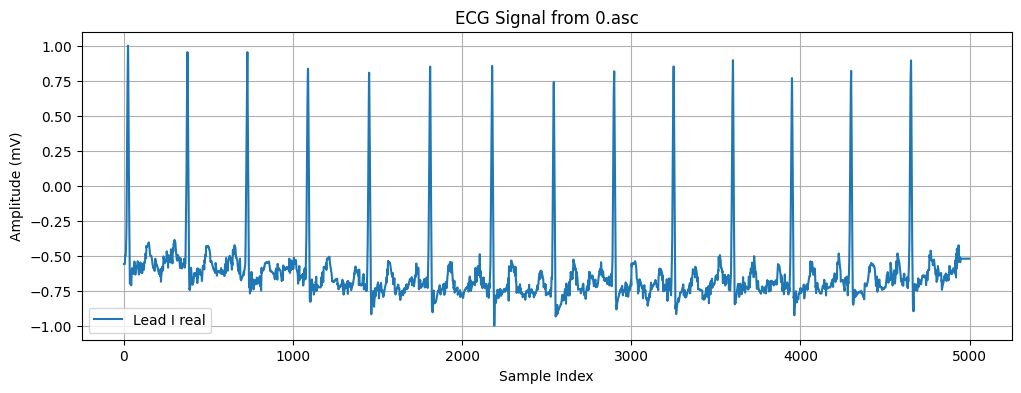

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(lead_I_real[1500], label="Lead I real")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (mV)")
plt.title("ECG Signal from 0.asc")
plt.legend()
plt.grid()
plt.show()

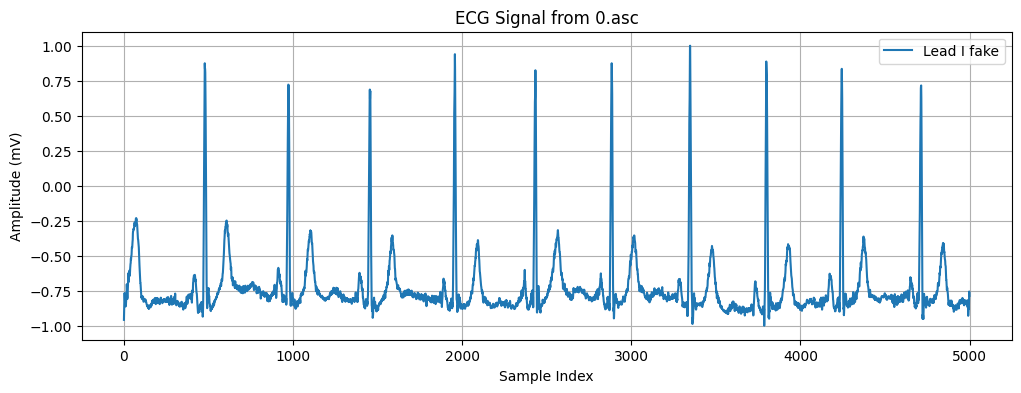

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(lead_I_fake[100], label="Lead I fake")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (mV)")
plt.title("ECG Signal from 0.asc")
plt.legend()
plt.grid()
plt.show()

In [6]:
# Combine data and labels
X = np.concatenate((lead_I_fake, lead_I_real), axis=0)  # Shape: (4000, samples_per_record)
y = np.concatenate((np.zeros(lead_I_fake.shape[0]), np.ones(lead_I_real.shape[0])), axis=0)  # Labels: 0 for fake, 1 for real

In [7]:
# Normalize the data (optional, depending on ECG value ranges)
# X = X.astype('float32') / np.max(np.abs(X))  # Normalize between -1 and 1

# Split the data into training and test sets (shuffle=True to mix real and fake ECGs)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Since ECG data is 1D, the input shape will be (samples_per_record, 1)
INPUT_SHAPE = (X_train.shape[1], 1)

# Reshape data to be in the format (samples, time_steps, 1)
X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_test = X_test.reshape(-1, X_test.shape[1], 1)

# Print the shapes of the datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (3200, 5000, 1)
X_test shape: (800, 5000, 1)


In [8]:
# CNN Model Architecture for 1D Data (ECG signals)
model = Sequential()

# Convolutional Layer
model.add(Conv1D(filters=32, kernel_size=3, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
# MaxPooling layer
model.add(MaxPooling1D(pool_size=2))
# Dropout layer
model.add(Dropout(0.25))

# Second Convolutional Block
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.25))

# Third Convolutional Block
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.25))

# Flatten layer
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
# Output layer (sigmoid activation for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
optimizer = Adam(learning_rate=0.005)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# EarlyStopping callback to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

# Train the model
batch_size = 32
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=batch_size,
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stop])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save the entire model to a HDF5 file
# model.save("my_ecg_model.h5")
# print("Model saved successfully.")

Epoch 1/50
100/100 [==============================] - 89s 850ms/step - loss: 6.4363 - accuracy: 0.6172 - val_loss: 0.7936 - val_accuracy: 0.4300
Epoch 2/50
100/100 [==============================] - 80s 802ms/step - loss: 0.6534 - accuracy: 0.7063 - val_loss: 6.9525 - val_accuracy: 0.5275
Epoch 3/50
100/100 [==============================] - 81s 807ms/step - loss: 0.5894 - accuracy: 0.7344 - val_loss: 3.0163 - val_accuracy: 0.5300
Epoch 4/50
100/100 [==============================] - 79s 792ms/step - loss: 0.5486 - accuracy: 0.7584 - val_loss: 1.4827 - val_accuracy: 0.5275
Epoch 5/50
100/100 [==============================] - 79s 792ms/step - loss: 0.4839 - accuracy: 0.7816 - val_loss: 1.3406 - val_accuracy: 0.5400
Epoch 6/50
100/100 [==============================] - 80s 802ms/step - loss: 0.4363 - accuracy: 0.8256 - val_loss: 5.0647 - val_accuracy: 0.6200
Epoch 7/50
100/100 [==============================] - 80s 805ms/step - loss: 0.3823 - accuracy: 0.8453 - val_loss: 0.7056 - val_ac

c:\Users\M2-Winterfell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


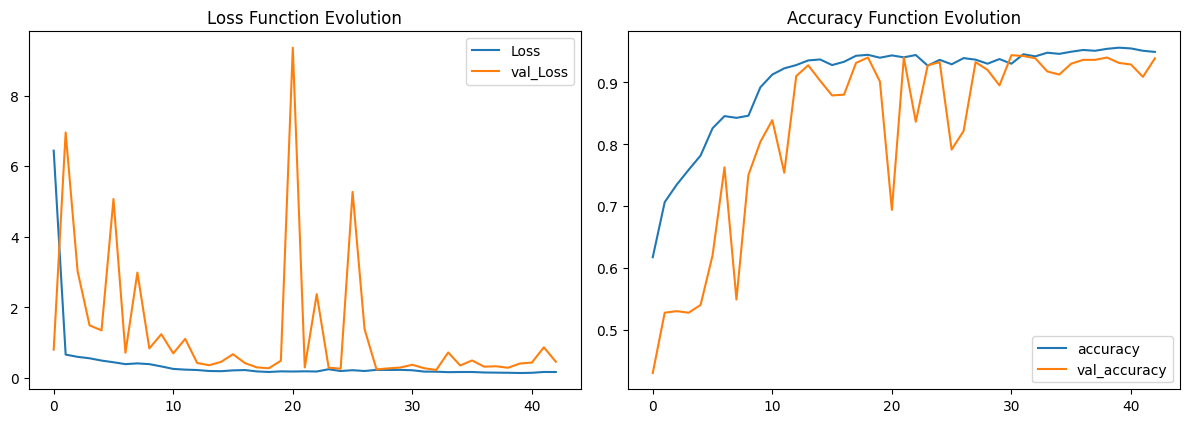

In [9]:
# Plotting
plt.figure(figsize=(12, 16))

# Loss plot
plt.subplot(4, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

# Accuracy plot
plt.subplot(4, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()


plt.tight_layout()
plt.show()

25/25 [==============================] - 6s 248ms/step - loss: 0.4507 - accuracy: 0.9388
Test Accuracy: 93.88%
25/25 [==============================] - 6s 240ms/step


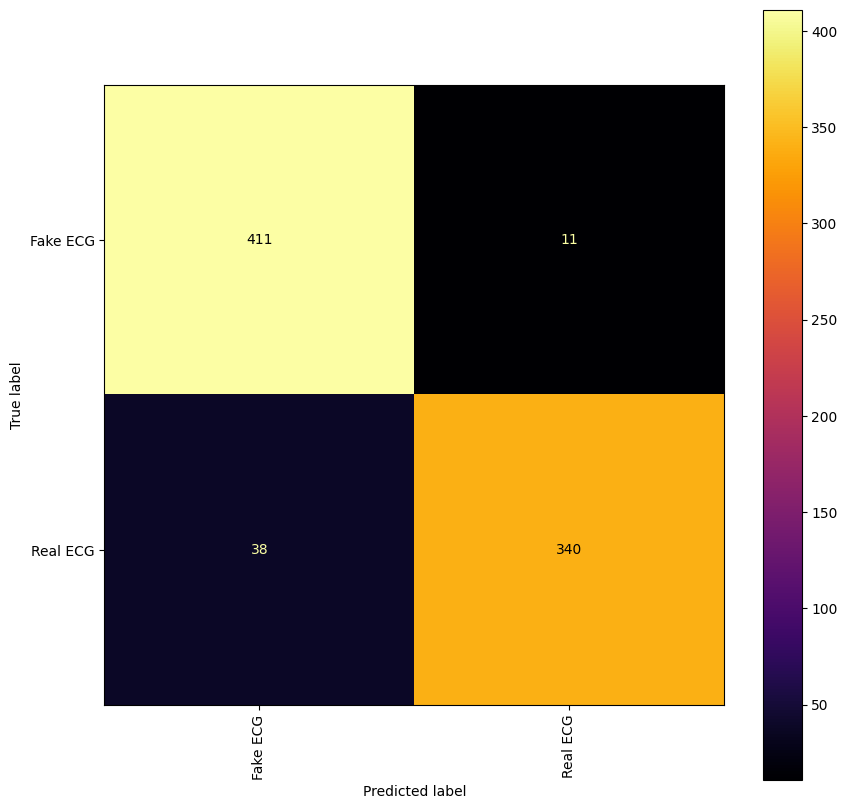

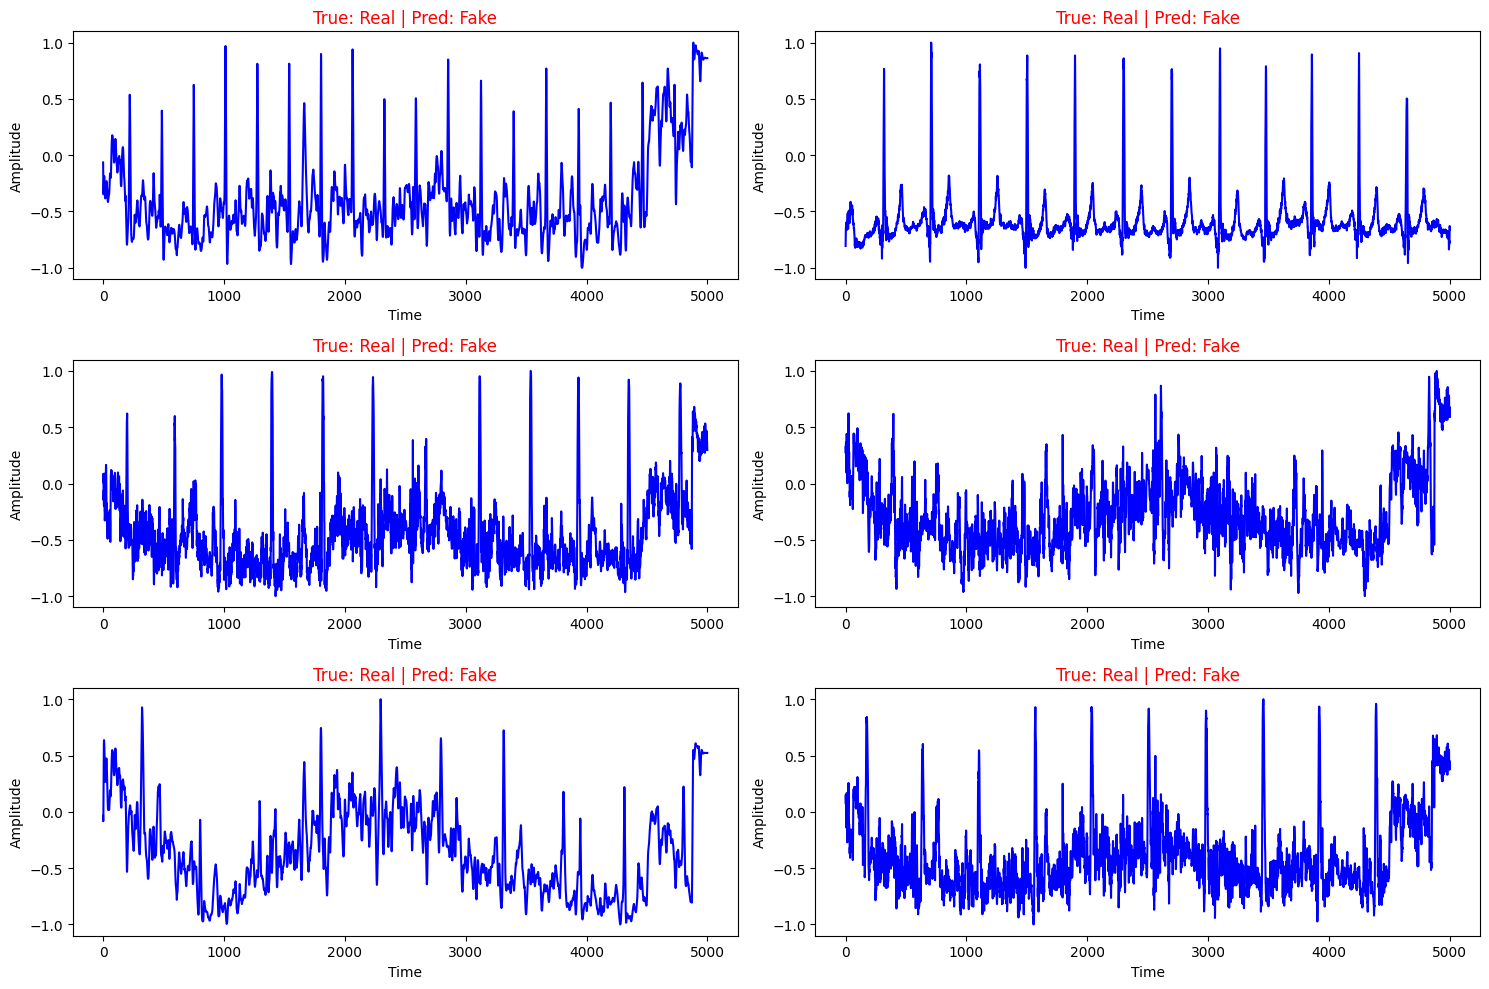

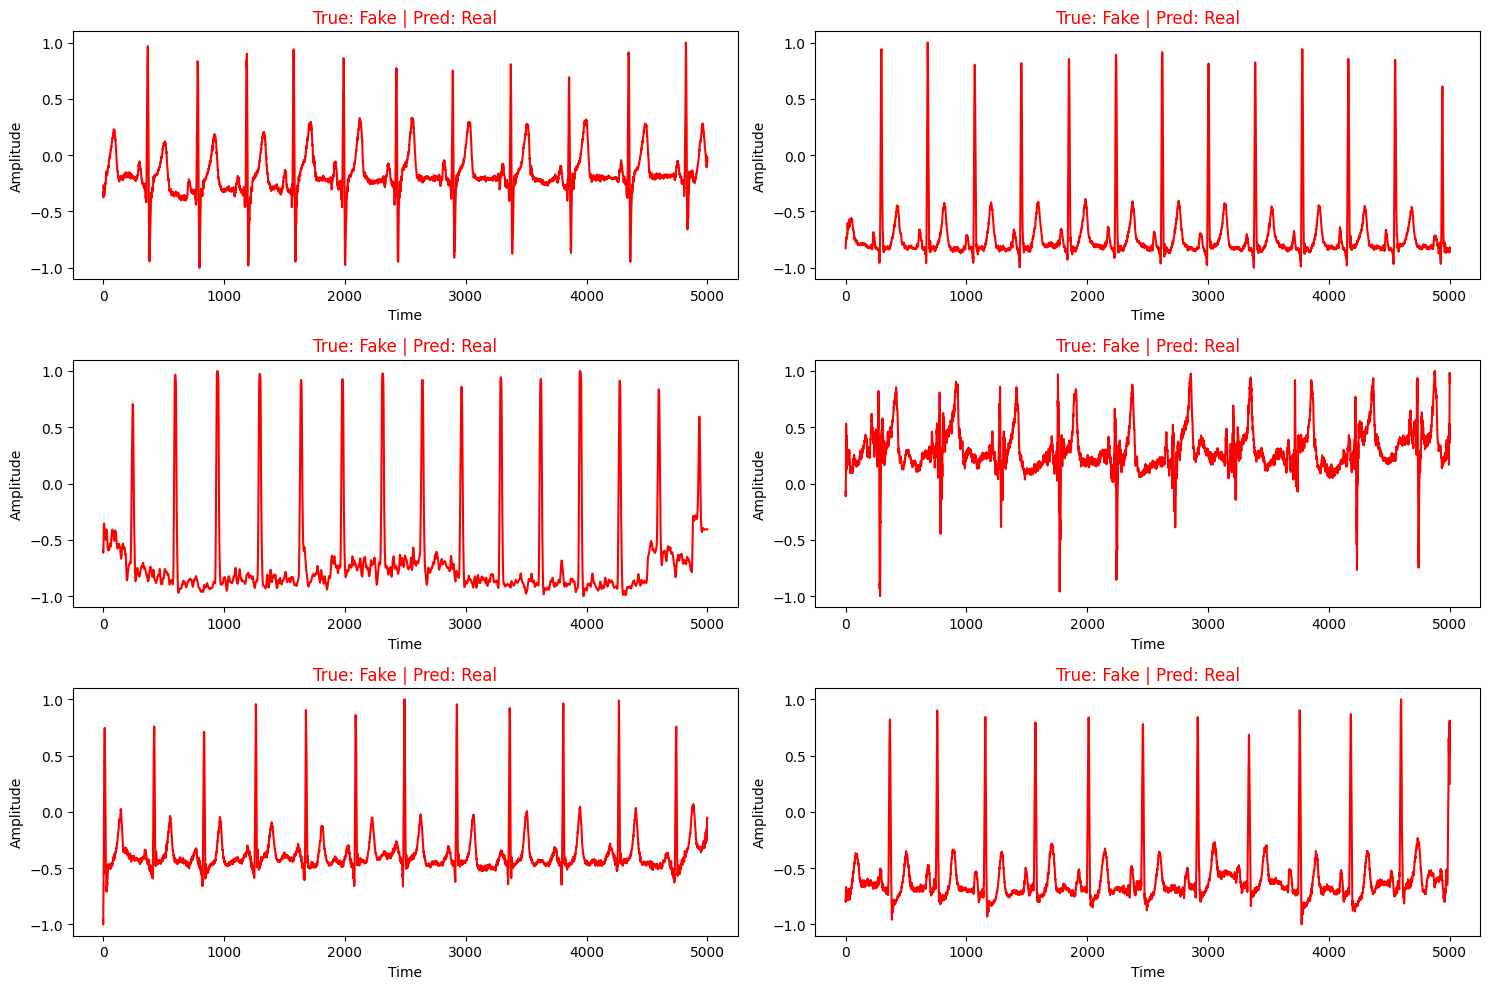

In [ ]:
# Model Evaluation
evaluation = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {evaluation[1] * 100:.2f}%')

# Predict on test set
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32").flatten()  # Convert probabilities to binary labels (0 or 1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake ECG", "Real ECG"])
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', ax=ax, cmap='inferno')
plt.show()

# -----------------------------------------------------------
# Plot 6 samples that are False Negatives
# -----------------------------------------------------------
false_negatives = [i for i in range(len(X_test)) if (y_test[i] == 1 and y_pred[i] == 0)]
num_fn = min(6, len(false_negatives))

if num_fn > 0:
    plt.figure(figsize=(15, 10))
    for j in range(num_fn):
        idx = false_negatives[j]
        plt.subplot(3, 2, j + 1)
        # True label is Real so plot in blue, but prediction is Fake
        plt.plot(X_test[idx].squeeze(), color='blue')
        plt.title("True: Real | Pred: Fake", color='red')
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()
else:
    print("No false negatives found.")

# -----------------------------------------------------------
# Plot 6 samples that are False Positives
# -----------------------------------------------------------
false_positives = [i for i in range(len(X_test)) if (y_test[i] == 0 and y_pred[i] == 1)]
num_fp = min(6, len(false_positives))

if num_fp > 0:
    plt.figure(figsize=(15, 10))
    for j in range(num_fp):
        idx = false_positives[j]
        plt.subplot(3, 2, j + 1)
        plt.plot(X_test[idx].squeeze(), color='red')
        plt.title("True: Fake | Pred: Real", color='red')
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()
else:
    print("No false positives found.")
